<a href="https://colab.research.google.com/github/rounak393/clab/blob/main/clab1(updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.1 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

import medmnist
from medmnist import INFO

In [3]:
data_flag = 'pathmnist'
download = True

info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

train_dataset = DataClass(split='train', download=download)
test_dataset = DataClass(split='test', download=download)

100%|██████████| 206M/206M [00:13<00:00, 15.5MB/s]


In [4]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
])

train_dataset.transform = transform
test_dataset.transform = transform

In [6]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [7]:
class FusionModel(nn.Module):

    def __init__(self, num_classes=9):
        super().__init__()

        self.mobilenet = models.mobilenet_v3_small(weights="DEFAULT")
        self.mobilenet.classifier = nn.Identity()

        self.efficientnet = models.efficientnet_b0(weights="DEFAULT")
        self.efficientnet.classifier = nn.Identity()

        self.fc = nn.Sequential(
            nn.Linear(576 + 1280, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        f1 = self.mobilenet(x)
        f2 = self.efficientnet(x)

        fused = torch.cat((f1, f2), dim=1)

        out = self.fc(fused)

        return out

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = FusionModel().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 141MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 162MB/s]


In [9]:
for param in model.mobilenet.parameters():
    param.requires_grad = False

for param in model.efficientnet.parameters():
    param.requires_grad = False

In [10]:
epochs = 5

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.squeeze().to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {running_loss/len(train_loader)}")

Epoch 1 Loss: 0.5598361624752959
Epoch 2 Loss: 0.3640671151490947
Epoch 3 Loss: 0.3266438254192948
Epoch 4 Loss: 0.3036762515206073
Epoch 5 Loss: 0.2885106519637755


In [ ]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.squeeze().to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print("Test Accuracy:", 100 * correct / total)

Test Accuracy: 88.32869080779945


In [11]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.squeeze().to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [12]:
print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1338
           1       0.90      1.00      0.95       847
           2       0.71      0.76      0.74       339
           3       0.94      0.94      0.94       634
           4       0.95      0.89      0.92      1035
           5       0.79      0.87      0.83       592
           6       0.91      0.86      0.88       741
           7       0.74      0.45      0.56       421
           8       0.88      0.93      0.90      1233

    accuracy                           0.89      7180
   macro avg       0.86      0.85      0.85      7180
weighted avg       0.89      0.89      0.89      7180



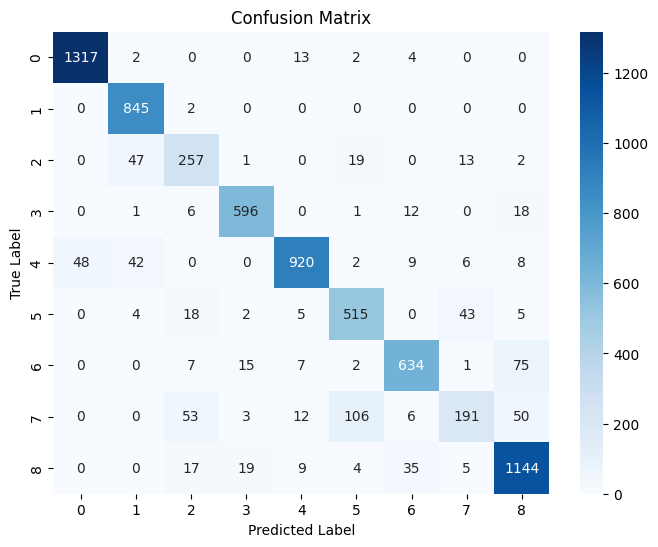

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

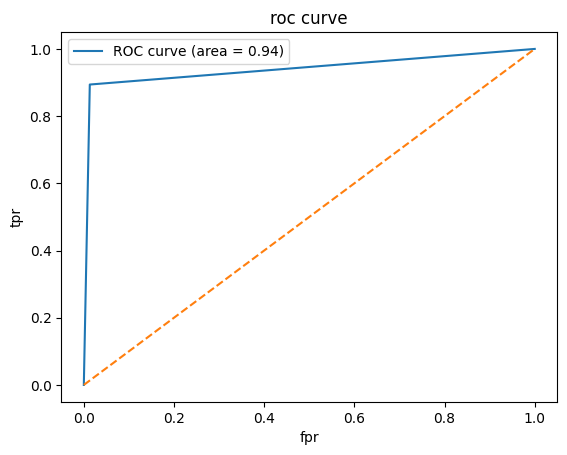

In [14]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true = label_binarize(all_labels, classes=np.unique(all_labels))
y_pred = label_binarize(all_preds, classes=np.unique(all_labels))

fpr, tpr, _ = roc_curve(y_true.ravel(), y_pred.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="ROC curve (area = %0.2f)" % roc_auc)
plt.plot([0,1],[0,1],'--')

plt.xlabel("fpr")
plt.ylabel("tpr")
plt.title("roc curve")
plt.legend()

plt.show()